In [1]:
import sys
sys.path.insert(0, '../')
import data_generation.SimulatorWaveEquation as simu
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs 
import matplotlib.tri as mtri
import weather_model_graphs as wmg 
from data_generation import DataPlotter as dp


c:\Users\maria\OneDrive - Danmarks Tekniske Universitet\Kandidat\Masters\code_masters\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
R = 1 # Radius
C = 1 # Wave speed
Lmax = 5 # Maximum degree of spherical harmonics
tmax = 10 # Maximum time  
generations = 1 # level of refinement for the grid
x0,y0,z0 = R,R,R # Initial position of the gaussian pulse
omega = C/R*np.sqrt(Lmax*(Lmax+1)) 
T_period = 2*np.pi/omega
dt = T_period/10 # Time step 
print("dt =", dt)

dt = 0.11471474419090952


In [3]:

# Initial condition: Gaussian pulse centered at (x0, y0, z0)
def f_handle(x, y, z):
    # dot product with center
    dot = x*x0 + y*y0 + z*z0
    
    cos_alpha = np.clip(dot / R**2, -1.0, 1.0)

    alpha = np.arccos(cos_alpha)
     
    return np.exp(-(alpha**2) / (2*0.2**2))

# Initital condition: zero initial velocity
g_handle = lambda x, y, z: 0 * x

In [4]:
sim = simu.SimulatorWaveEquation(R=1.0, C=C, Lmax=Lmax, tmax=tmax, f_handle=f_handle, g_handle=g_handle, generations=generations,dt=dt)


In [5]:
print("clf val:",sim.clf_value)
print("dt:",sim.dt)
print("dx:",sim.dx)
print()

clf val: 0.20971956787638368
dt: 0.11471474419090952
dx: 0.5469911336958626



In [6]:
title = f"test_graph_data/wave_sphere_data"
ds = sim.simulate(title=title, savedata=True, savegraph=False)  # (time, N) 


In [7]:
long = ds['lon'].values
lat = ds['lat'].values
tri = ds['tri'].values

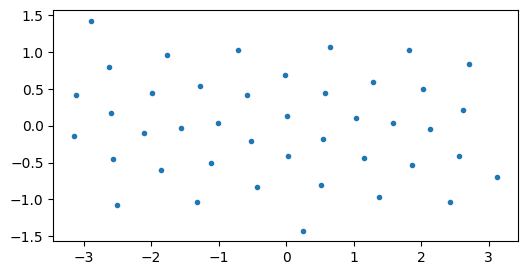

In [8]:
coords = np.stack([long, lat], axis=1)   # (N,2)

fig, ax = plt.subplots(figsize=(6,3))
ax.scatter(coords[:, 0], coords[:, 1], marker=".")


2026-03-06 14:49:15.815 | DEBUG    | weather_model_graphs.create.base:create_all_graph_components:108 - No `coords_crs` given: Assuming `coords` contains in-projection Cartesian coordinates.


<GeoAxes: >

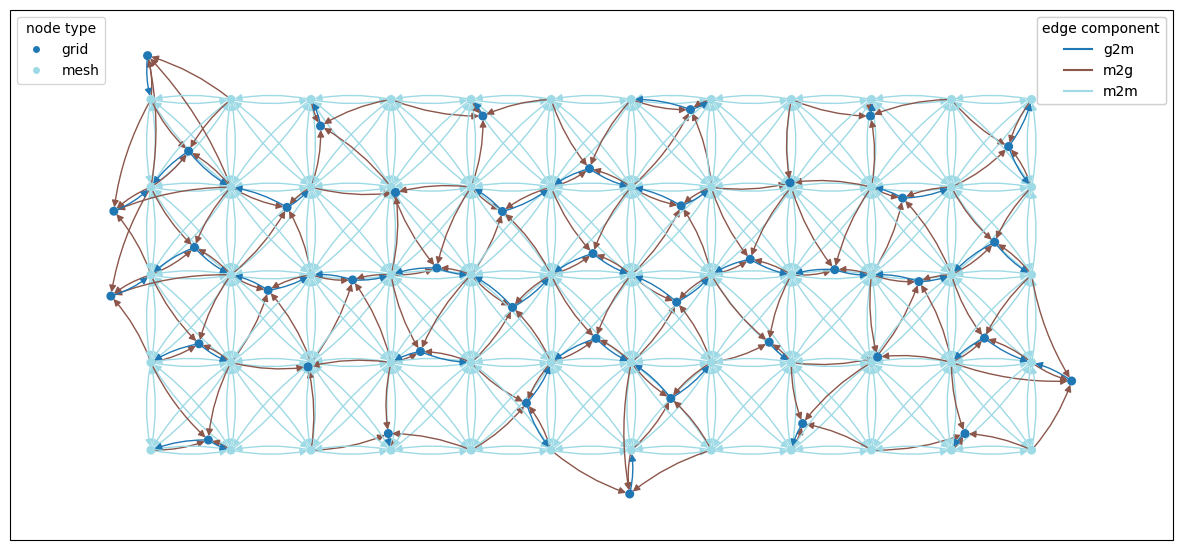

In [9]:
graph_keisler = wmg.create.archetype.create_keisler_graph(coords, mesh_node_distance=0.5)
fig, ax = plt.subplots(figsize=(15, 9), subplot_kw={"projection": ccrs.PlateCarree()})
wmg.visualise.nx_draw_with_pos_and_attr(
    graph_keisler, ax=ax, node_size=30, edge_color_attr="component", node_color_attr="type"
)

2026-03-06 14:49:22.248 | DEBUG    | weather_model_graphs.create.base:create_all_graph_components:122 - Projecting coords from CRS(+proj=eqc +ellps=WGS84 +a=6378137.0 +lon_0=0.0 +to_meter=111319.4907932736 +vto_meter=1 +no_defs +type=crs) to CRS(+proj=eqc +ellps=WGS84 +a=6378137.0 +lon_0=0.0 +to_meter=111319.4907932736 +vto_meter=1 +no_defs +type=crs) for graph creation.
2026-03-06 14:49:22.265 | DEBUG    | weather_model_graphs.create.mesh.mesh:create_multirange_2d_mesh_graphs:134 - mesh_levels: 1, nleaf: [9 3]


<GeoAxes: >

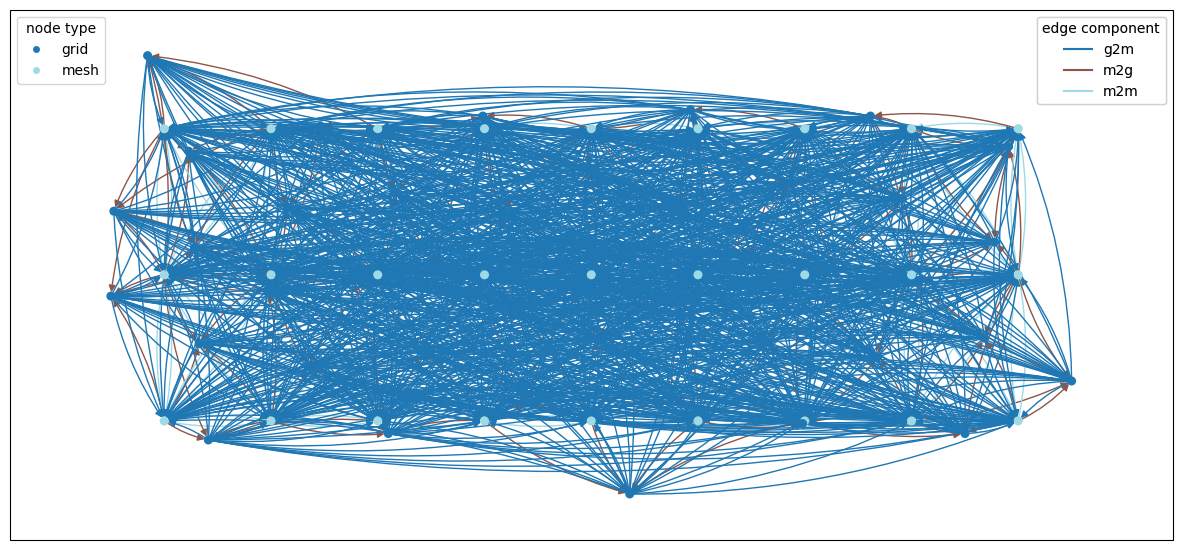

In [10]:
graph_cast = wmg.create.archetype.create_graphcast_graph(coords,mesh_node_distance=0.5,coords_crs=ccrs.PlateCarree(),graph_crs=ccrs.PlateCarree())
fig, ax = plt.subplots(figsize=(15, 9), subplot_kw={"projection": ccrs.PlateCarree()})
wmg.visualise.nx_draw_with_pos_and_attr(
    graph_cast, ax=ax, node_size=30, edge_color_attr="component", node_color_attr="type"
)

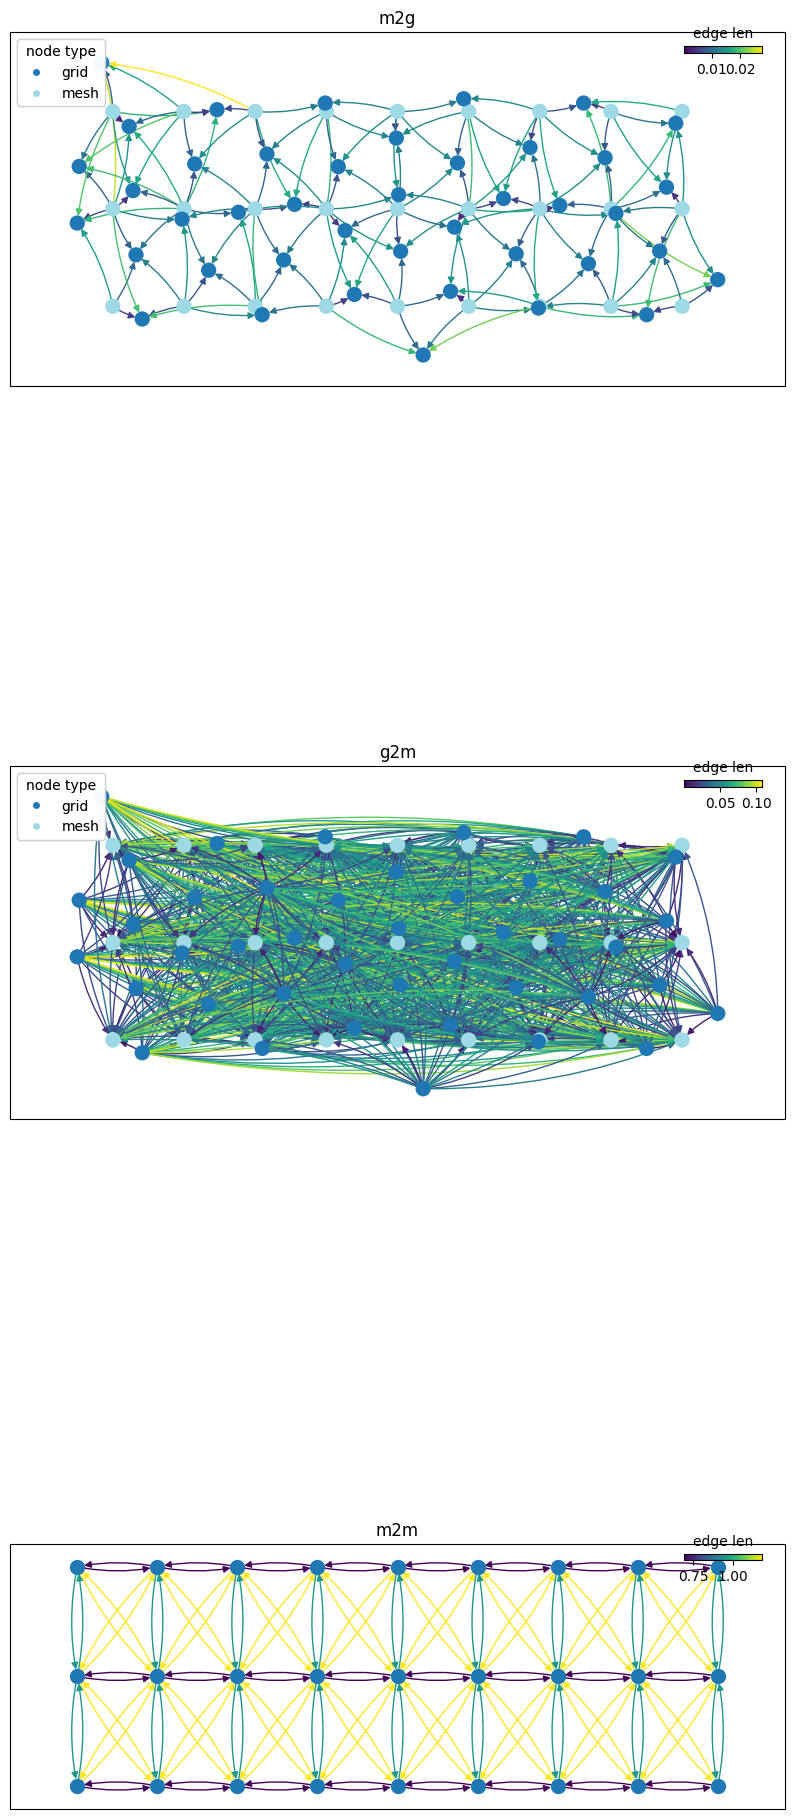

In [11]:
graph_components = wmg.split_graph_by_edge_attribute(graph=graph_cast, attr="component")

n_components = len(graph_components)
fig, axes = plt.subplots(nrows=n_components, ncols=1, figsize=(10, 9 * n_components), subplot_kw={"projection": ccrs.PlateCarree()})

for (name, g), ax in zip(graph_components.items(), axes.flatten()):
    pl_kwargs = {}
    if name == "m2m":
        pl_kwargs = dict(edge_color_attr="len")
    elif name == "g2m" or name == "m2g":
        pl_kwargs = dict(edge_color_attr="len", node_color_attr="type")

    wmg.visualise.nx_draw_with_pos_and_attr(graph=g, ax=ax, **pl_kwargs)
    ax.set_title(name)
    ax.set_aspect(1.0)

plt.savefig("../figures/test/split_graphs_graph_cast.png")
plt.show()